El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales con la implementación de técnicas de regularización, con un total de 6 capas reemplazando Upsampling por Convtrasnpuesta

Importación de librerías

In [5]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
import matplotlib.pyplot as plt

Funciones:

In [6]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [7]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [8]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_original = "E:/bandas/banda13/ene_01_mes"
d_reducida = 'E:/bandas/banda13/ene_01_reducida_mes'

#Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]  # Limita los valores al rango [0, 1]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 741 imágenes
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [9]:
# Semilla
semilla = 42
tf.random.set_seed(semilla)

# Definición del modelo
model3 = Sequential([
    # Encoder
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Bottleneck
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    # Decoder con Conv2DTranspose en lugar de UpSampling
    Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same'),
    BatchNormalization(),

    Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu', padding='same'),
    BatchNormalization(),

    # Output
    Conv2D(1, (3, 3), activation='sigmoid', padding='same')
])

# Compilación
model3.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo:")
model3.summary()

# Entrenamiento con EarlyStopping
print("Iniciando entrenamiento de prueba...")

checkpoint = ModelCheckpoint(
    filepath="mejor_modelo.h5",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

history3 = model3.fit(
    X, y,
    epochs=15,
    batch_size=8,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("¡Prueba completada!")
print(f"Pérdida final: {history3.history['loss'][-1]:.4f}")

Resumen del modelo:


c:\Users\jhona\python1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 480, 480, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 240, 240, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 240, 240, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 120, 120, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 120, 120, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 240, 240, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 240, 240, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 480, 480, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 480, 480, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 480, 480, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,497 (728.50 KB)

...

93/93 ━━━━━━━━━━━━━━━━━━━━ 86s 925ms/step - loss: 0.0077 - mean_absolute_percentage_error: 1067.6636 - root_mean_squared_error: 0.0880
Epoch 12/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - loss: 0.0076 - mean_absolute_percentage_error: 967.1682 - root_mean_squared_error: 0.0874

93/93 ━━━━━━━━━━━━━━━━━━━━ 86s 920ms/step - loss: 0.0077 - mean_absolute_percentage_error: 1063.6191 - root_mean_squared_error: 0.0879
Epoch 13/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - loss: 0.0076 - mean_absolute_percentage_error: 971.7003 - root_mean_squared_error: 0.0871

93/93 ━━━━━━━━━━━━━━━━━━━━ 86s 921ms/step - loss: 0.0077 - mean_absolute_percentage_error: 1070.4374 - root_mean_squared_error: 0.0876
Epoch 14/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - loss: 0.0075 - mean_absolute_percentage_error: 998.3013 - root_mean_squared_error: 0.0867

93/93 ━━━━━━━━━━━━━━━━━━━━ 86s 919ms/step - loss: 0.0076 - mean_absolute_percentage_error: 1087.9833 - root_mean_squared_error: 0.0875
Epoch 15/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - loss: 0.0078 - mean_absolute_percentage_error: 957.1180 - root_mean_squared_error: 0.0885

93/93 ━━━━━━━━━━━━━━━━━━━━ 85s 915ms/step - loss: 0.0078 - mean_absolute_percentage_error: 1059.4275 - root_mean_squared_error: 0.0885
¡Prueba completada!
Pérdida final: 0.0078


Valores de las metricas

In [10]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model3.evaluate(X, y, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 565ms/step - loss: 0.0102 - mean_absolute_percentage_error: 965.3839 - root_mean_squared_error: 0.1008
Pérdida (MSE): 0.0102
RMSE: 0.1008
MAPE: 965.3839


Visualización de imagenes

24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 554ms/step


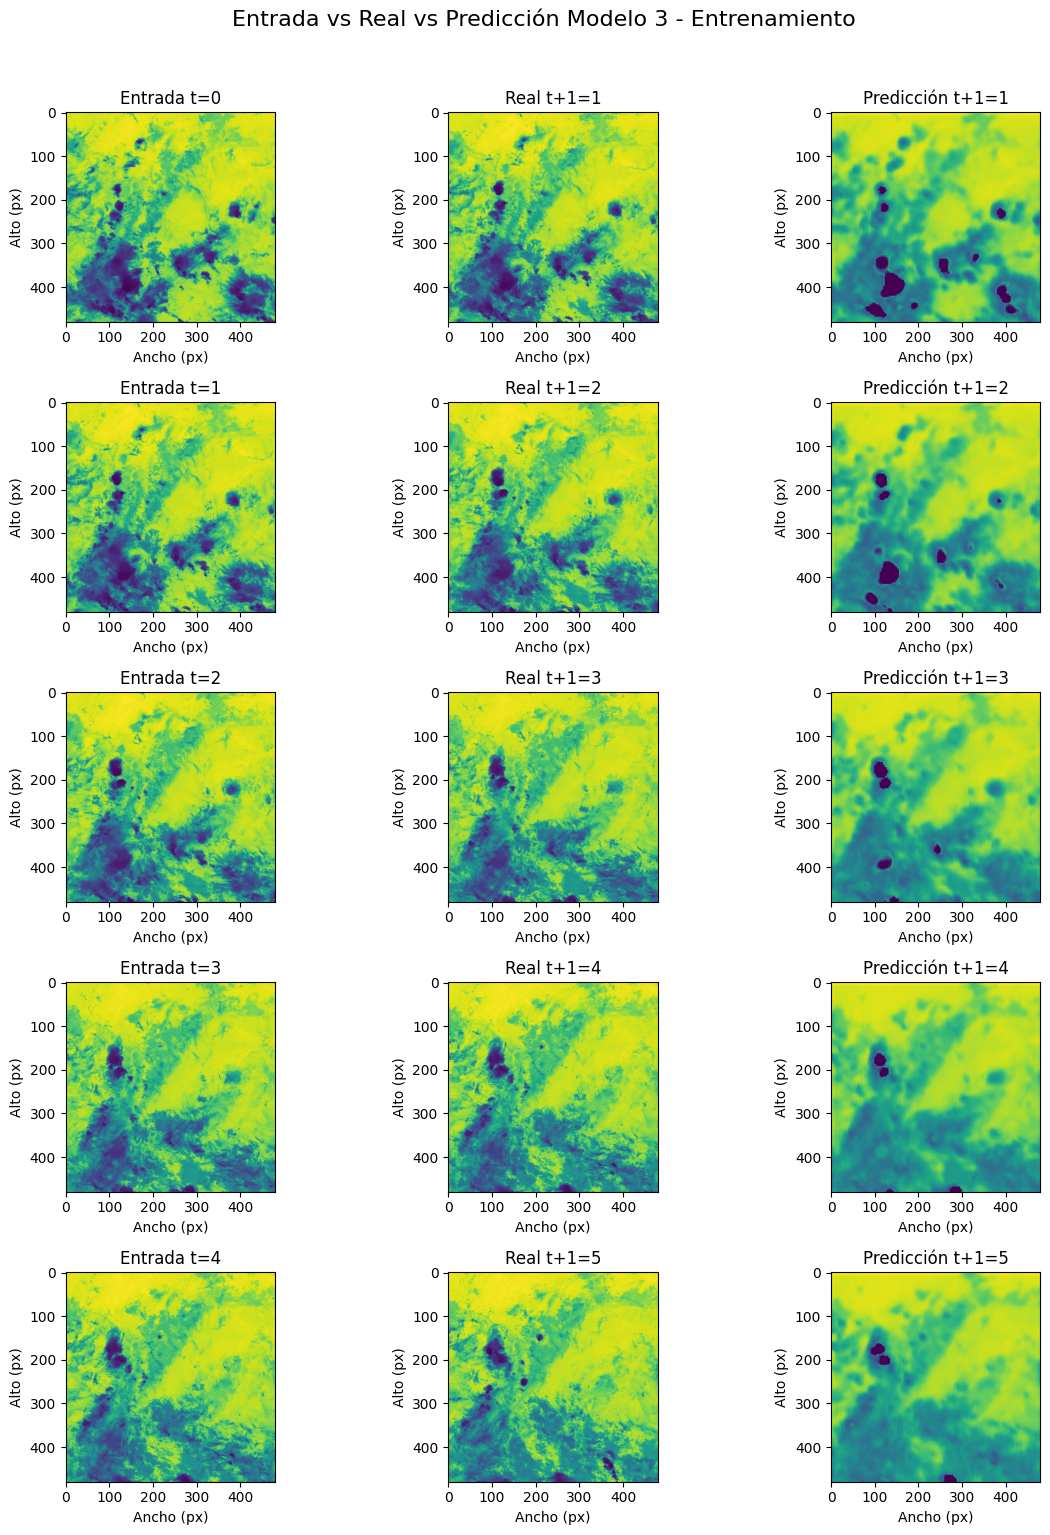

In [11]:
y_pred3 = model3.predict(X)  # Genera las predicciones
mostrar_resultados(
    X, y, y_pred3, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 3 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 552ms/step


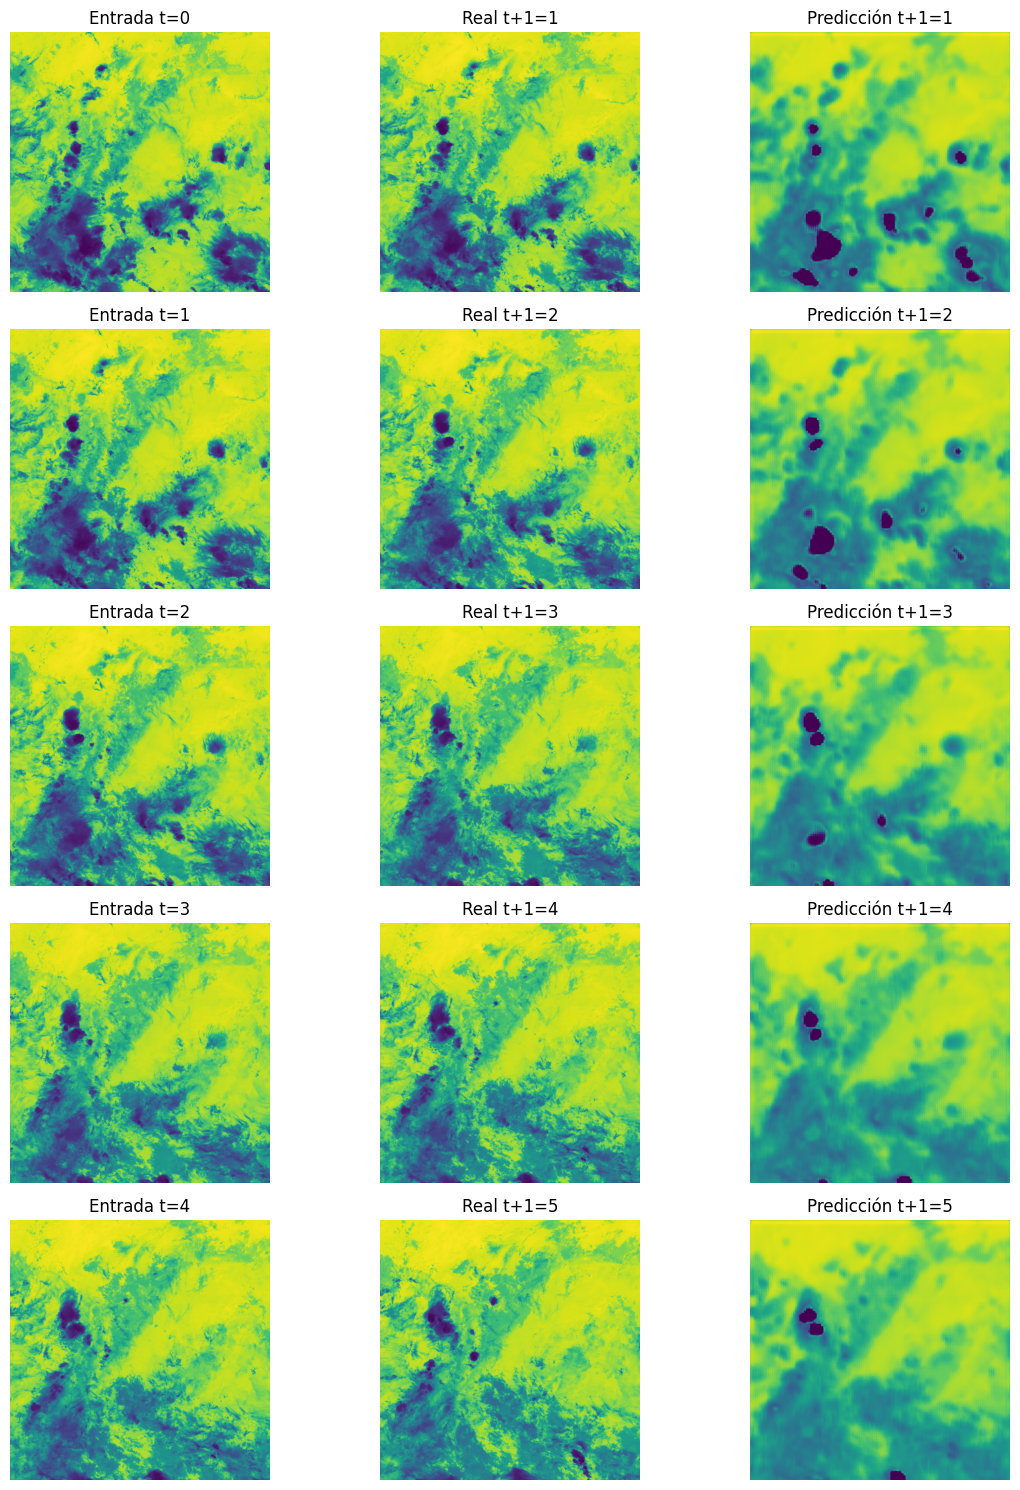

In [12]:
y_pred3 = model3.predict(X)  # Genera las predicciones

# Selecciona el número de ejemplos a mostrar
n = 5

# Muestra imágenes reales vs predichas usando un mapa de color
fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))

for i in range(n):
    axs[i, 0].imshow(X[i, ..., 0], cmap='viridis')
    axs[i, 0].set_title(f'Entrada t={i}')
    axs[i, 0].axis('off')

    axs[i, 1].imshow(y[i, ..., 0], cmap='viridis')
    axs[i, 1].set_title(f'Real t+1={i+1}')
    axs[i, 1].axis('off')

    axs[i, 2].imshow(y_pred3[i, ..., 0], cmap='viridis')
    axs[i, 2].set_title(f'Predicción t+1={i+1}')
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()

Validación

In [13]:
# Directorio original y reducido
d_feb_1s = 'E:/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = 'E:/bandas/banda13/feb_01_07_1s_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_val = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple
images_val = [(img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8) for img in images_val]
images_val = [np.clip(img, 0, 1) for img in images_val]  # Limita los valores al rango [0, 1]

X_val = np.array(images_val[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_val = np.array(images_val[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_val.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_val.shape}")  # Imprime la forma del array de salida

Procesando 167 imágenes
Forma de X: (166, 480, 480, 1)
Forma de y: (166, 480, 480, 1)


Metricas de validación

In [14]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model3.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 502ms/step - loss: 0.0200 - mean_absolute_percentage_error: 814.7495 - root_mean_squared_error: 0.1415
Pérdida (MSE): 0.0200
RMSE: 0.1415
MAPE: 814.7495


Visualización de imagenes con conjunto de validación

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 486ms/step


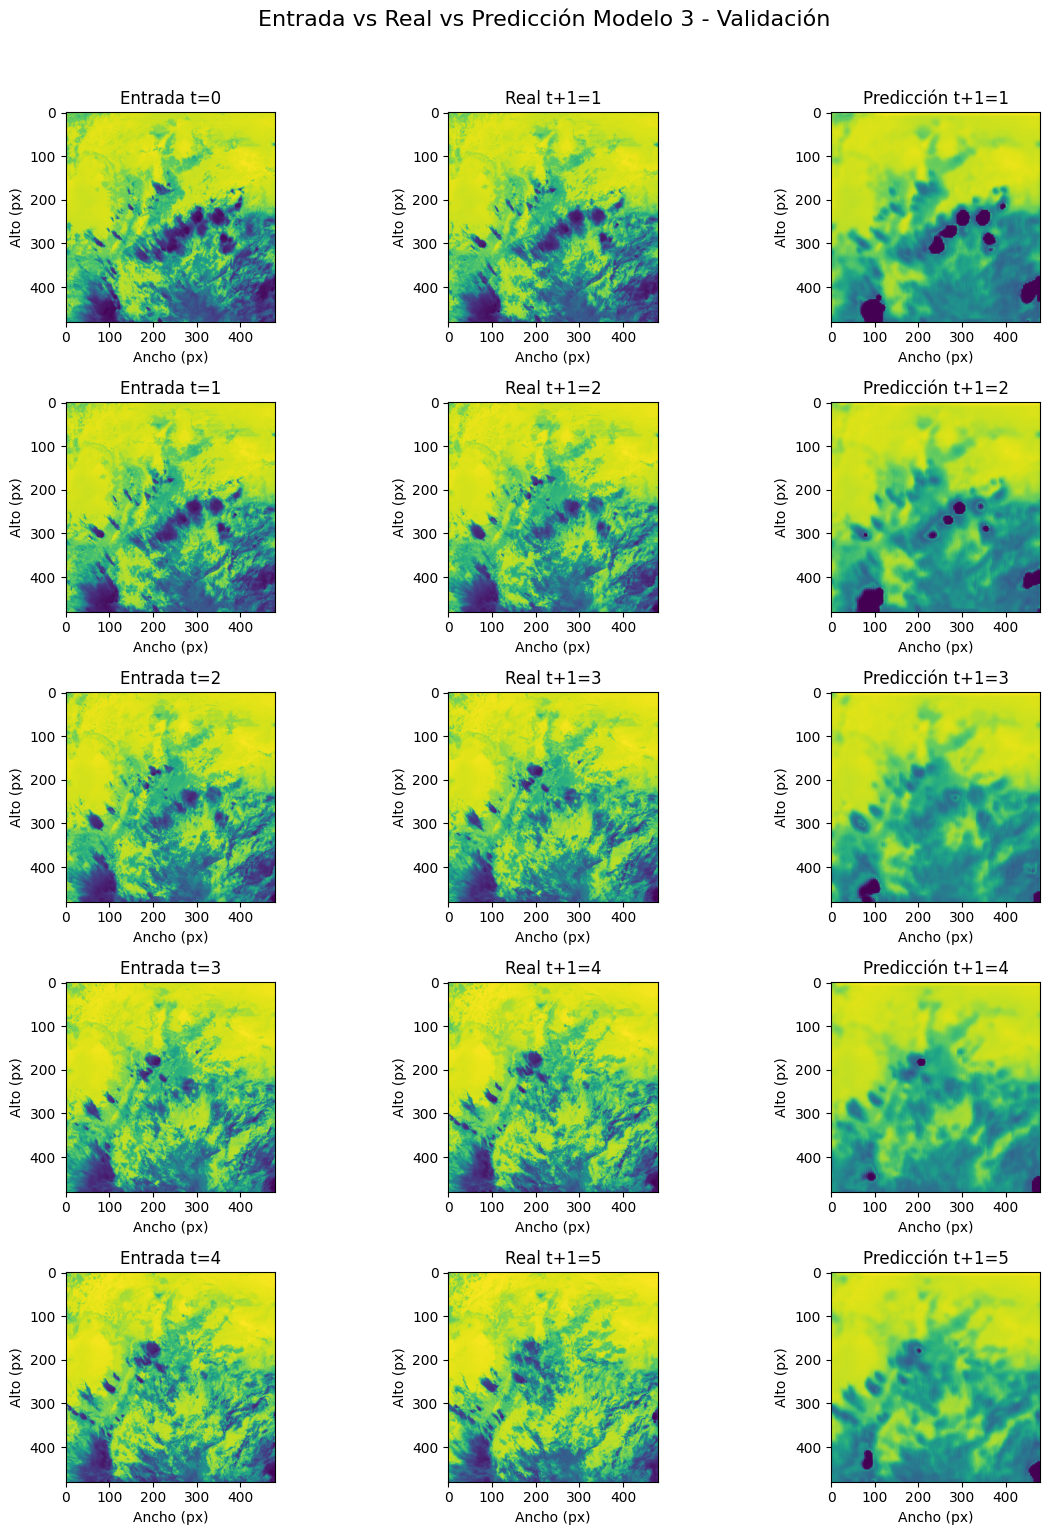

In [ ]:



y_pred3_val = model3.predict(X_val)  # Genera las predicciones
mostrar_resultados(
    X_val, y_val, y_pred3_val, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 3 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)